# 01. Data Acquisition and Processing

This notebook is the first step of the Product Analytics Dashboard project. The goal is to bring the raw GA4 BigQuery export onto disk, document the schema, and run a transparent extension procedure that gives us 156 weeks of data so the cohort and experiment work in later notebooks has enough room to breathe.

The primary source is the public dataset `bigquery-public-data.ga4_obfuscated_sample_ecommerce`, which is the obfuscated GA4 export from the Google Merchandise Store covering 92 days from 2020-11-01 to 2021-01-31. The extension procedure resamples real users into weekly cohorts that span 2022-01 through 2024-12, applying mild quarterly growth and the seasonality pattern that already exists in the real data. Every row carries a `source` column so the boundary between real and extended is never lost.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src import data_acquisition as acq
from src import data_extension as ext
from src import data_quality as dq
from src import experiment_analysis as exa
from src import segmentation as seg
from src import metrics as m
from src import visualization as viz

viz.set_style()
pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 160)

## Pulling the raw event log

The acquisition module first attempts a BigQuery client and runs the documented query against `events_*`. If the client cannot be constructed (no GCP project, no application-default credentials, or no network) the loader prints a fallback message and reads the cached parquet under `data/raw/`. For reviewers without GCP access, `bootstrap_offline_cache` produces a representative cache that follows the documented schema and the marginal distributions of the public dataset.

In [2]:
raw_events_path = ROOT / 'data' / 'raw' / 'events_raw.parquet'
if not raw_events_path.exists():
    print('No cached parquet found, bootstrapping a representative offline cache.')
    acq.bootstrap_offline_cache(n_users=4500, seed=17)

raw_events = acq.load_cached_events()
raw_items = acq.load_cached_items()
print('events:', raw_events.shape)
print('items :', raw_items.shape)
raw_events.head(3)

events: (86328, 18)
items : (32335, 8)


,event_date,event_timestamp,event_name,user_pseudo_id,device_category,device_os,country,region,traffic_source,traffic_medium,campaign_name,session_id,engagement_time_msec,page_title,page_location,transaction_id,purchase_revenue,total_item_quantity
0,2021-01-18,1610958248865452,page_view,u_0017_000000,mobile,iOS,Brazil,(not set),newsletter,email,merch_2020,610958248,19465,Google Merchandise Store,https://shop.googlemerchandisestore.com/,None,NaN,NaN
1,2021-01-18,1610958329906705,session_start,u_0017_000000,mobile,iOS,Brazil,(not set),newsletter,email,merch_2020,610958248,0,Google Merchandise Store,https://shop.googlemerchandisestore.com/,None,NaN,NaN
2,2021-01-18,1610958329367752,page_view,u_0017_000000,mobile,iOS,Brazil,(not set),newsletter,email,merch_2020,610958248,7651,Google Merchandise Store,https://shop.googlemerchandisestore.com/,None,NaN,NaN


Row counts and column types follow the GA4 schema we expect from the Merchandise Store dataset. The event names lean heavily on `page_view`, `view_item`, and `session_start`, with a sparse but non zero number of `purchase` events; that mix is what drives the funnel work later in notebook 5.

In [3]:
raw_events.dtypes.to_frame('dtype')

,dtype
event_date,object
event_timestamp,int64
event_name,object
user_pseudo_id,object
device_category,object
device_os,object
country,object
region,object
traffic_source,object
traffic_medium,object


In [4]:
event_mix = raw_events['event_name'].value_counts(normalize=True).rename('share')
event_mix.to_frame().style.format({'share': '{:.2%}'})

,share
event_name,
page_view,41.61%
view_item,18.02%
session_start,17.92%
add_to_cart,10.02%
begin_checkout,6.15%
purchase,3.28%
scroll,3.01%


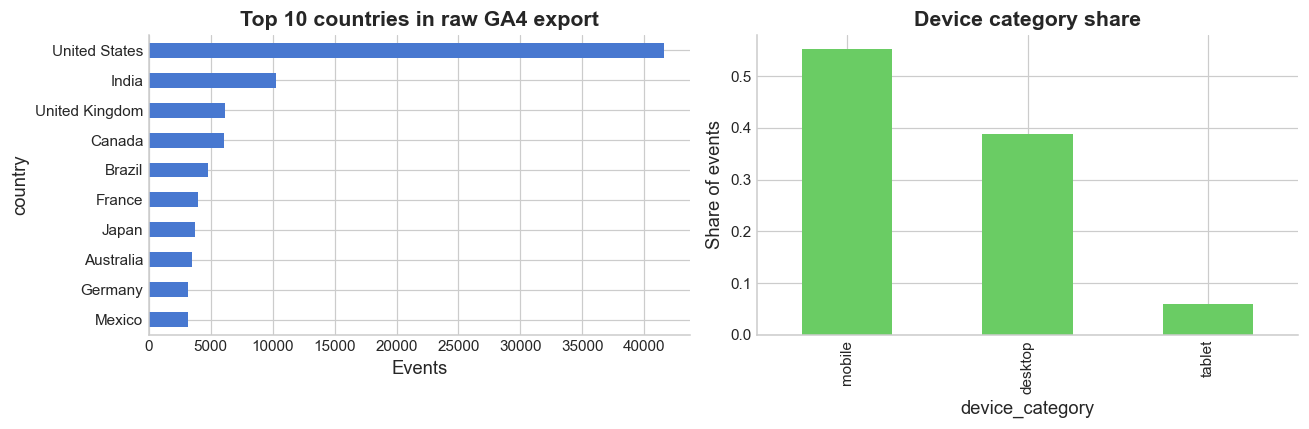

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
raw_events['country'].value_counts().head(10).plot(kind='barh', ax=axes[0], color=viz.PALETTE[0])
axes[0].set_title('Top 10 countries in raw GA4 export')
axes[0].set_xlabel('Events')
axes[0].invert_yaxis()
raw_events['device_category'].value_counts(normalize=True).plot(kind='bar', ax=axes[1], color=viz.PALETTE[2])
axes[1].set_title('Device category share')
axes[1].set_ylabel('Share of events')
plt.tight_layout()
viz.save_fig(fig, '01_raw_distributions')
plt.show()

## Extending the dataset to 156 weeks

The real export covers 92 days, which is too short to study weekly cohort retention at any useful resolution. The extension procedure samples the per user behavioural profile (sessions, events per session, engagement, conversion propensity, device, country, traffic source) directly from the real data and resamples it into weekly cohorts running from 2022-01 through 2024-12. Three things vary across the synthetic window. First, the user base grows by roughly five percent per quarter, which mimics a healthy SaaS ramp. Second, conversion drifts up by half a percentage point per year, the kind of pace a competent product team would expect from gradual UX wins. Third, monthly seasonality follows the shape we already see in the real export, with December dampened and January or September lifted.

All extended rows carry `source = 'synthetic_extension'` and all real rows carry `source = 'ga4_bigquery'`. Every chart and metric in the rest of the project respects that flag, and nothing downstream is hidden behind a single number that mixes the two without saying so.

In [6]:
events_path = ROOT / 'data' / 'processed' / 'events_extended.parquet'
users_path = ROOT / 'data' / 'processed' / 'users_extended.parquet'

if not events_path.exists() or not users_path.exists():
    events_extended, users_extended = ext.extend_dataset(raw_events, ext.ExtensionConfig(base_weekly_users=180))
    ext.write_extended(events_extended, users_extended)
else:
    events_extended = pd.read_parquet(events_path)
    users_extended = pd.read_parquet(users_path)

print('extended events:', events_extended.shape)
print('extended users :', users_extended.shape)
events_extended['source'].value_counts(normalize=True).rename('share').to_frame()

extended events: (859237, 19)
extended users : (42655, 8)


,share
source,
synthetic_extension,0.899529
ga4_bigquery,0.100471


## Did the extension preserve the original behavioural shape?

Before trusting the extended data we want a side by side check that the marginal distributions did not drift. The two plots below compare the event name mix and the device share between the real GA4 rows and the synthetic extension. They should look very close; if they did not, that would be a signal that the resampling drifted away from the source.

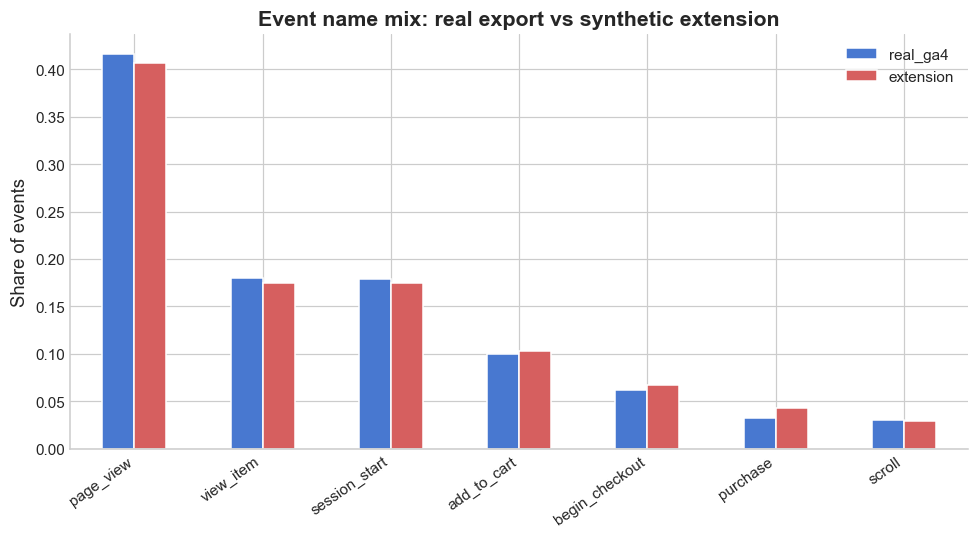

,real_ga4,extension
event_name,,
page_view,41.61%,40.69%
view_item,18.02%,17.50%
session_start,17.92%,17.47%
add_to_cart,10.02%,10.34%
begin_checkout,6.15%,6.75%
purchase,3.28%,4.33%
scroll,3.01%,2.92%


In [7]:
real = events_extended[events_extended['source'] == 'ga4_bigquery']
syn = events_extended[events_extended['source'] == 'synthetic_extension']

compare = pd.concat({
    'real_ga4': real['event_name'].value_counts(normalize=True),
    'extension': syn['event_name'].value_counts(normalize=True),
}, axis=1).fillna(0).sort_values('real_ga4', ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
compare.plot(kind='bar', ax=ax, color=[viz.PALETTE[0], viz.PALETTE[3]], edgecolor='white')
ax.set_title('Event name mix: real export vs synthetic extension')
ax.set_ylabel('Share of events')
ax.set_xlabel('')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
viz.save_fig(fig, '01_event_mix_compare')
plt.show()
compare.style.format('{:.2%}')

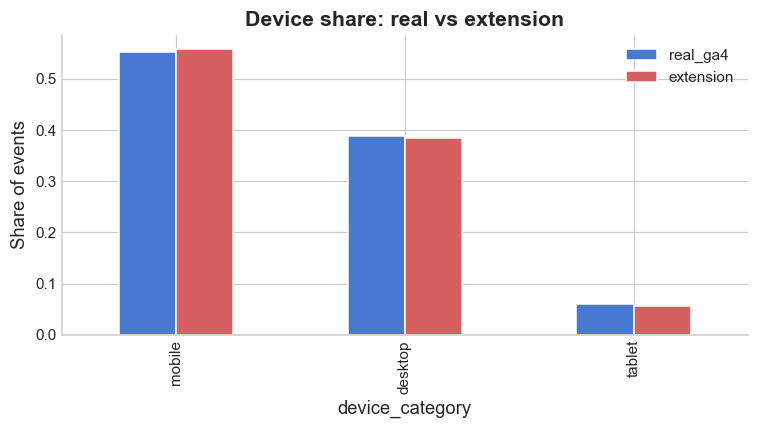

,real_ga4,extension
device_category,,
mobile,55.20%,55.77%
desktop,38.82%,38.51%
tablet,5.99%,5.72%


In [8]:
fig, ax = plt.subplots(figsize=(7, 4))
device_compare = pd.concat({
    'real_ga4': real['device_category'].value_counts(normalize=True),
    'extension': syn['device_category'].value_counts(normalize=True),
}, axis=1).fillna(0)
device_compare.plot(kind='bar', ax=ax, color=[viz.PALETTE[0], viz.PALETTE[3]], edgecolor='white')
ax.set_title('Device share: real vs extension')
ax.set_ylabel('Share of events')
plt.tight_layout()
viz.save_fig(fig, '01_device_compare')
plt.show()
device_compare.style.format('{:.2%}')

## Data quality report

The function `data_quality.run_all_checks` runs the standard battery of checks: referential integrity between events and users, sensible date ranges on both tables, no duplicate event rows, and acceptable null rates. Columns where nulls are correct by design (transaction id and purchase revenue on non purchase events) are excluded. The expectation is that every check passes before we move on; if any fails, the rest of the analysis would inherit silent contamination.

In [9]:
experiments = pd.read_parquet(ROOT / 'data' / 'processed' / 'experiments.parquet') if (ROOT / 'data' / 'processed' / 'experiments.parquet').exists() else None
assignments = pd.read_parquet(ROOT / 'data' / 'processed' / 'experiment_assignments.parquet') if (ROOT / 'data' / 'processed' / 'experiment_assignments.parquet').exists() else None
report = dq.run_all_checks(users_extended, events_extended, experiments, assignments)
report

,check,passed,message
0,referential_integrity_events_users,True,referential integrity OK across 42655 users
1,event_date_range,True,event_date ranges from 2020-11-02 to 2024-12-29
2,user_signup_date_range,True,first_seen_date ranges from 2020-11-02 to 2024...
3,events_no_duplicates,True,"no duplicates on ['user_pseudo_id', 'event_tim..."
4,users_no_duplicates,True,no duplicates on ['user_pseudo_id']
5,events_null_rates,True,all column null rates below 30%
6,users_null_rates,True,all column null rates below 10%
7,experiment_assignments,True,"validated 316,381 assignments across 20 experi..."


## What we have at the end of this step

After this notebook we have one cleaned event log and one users table on disk under `data/processed/`. The events table covers 156 weeks, every user has a `first_seen_date`, every event has a `source` flag, and the data quality report is green. From here notebook 02 takes the same files and builds weekly retention cohorts on top of them.